# FF++ Xception Training: Per-Method Specialists, Universal Model, and Meta-Router Ensemble

This script trains, on the same FaceForensics++ (c23) extracted-frame dataset used by the
UniversalFakeDetect notebook, a from-scratch/pretrained-Xception pipeline in three stages:

1. **Stage 1** - Five method-specific binary classifiers (real vs. one fake method each).
2. **Stage 2** - One "Universal" binary classifier trained on the full dataset (all methods).
3. **Stage 3** - A 6-way "router" model that, for each image, predicts {Real, Deepfakes,
   Face2Face, FaceShifter, FaceSwap, NeuralTextures} and dispatches fake predictions to the
   matching Stage-1 specialist. The specialist's own sigmoid score becomes the final
   fake-probability for that image; images routed to "Real" use the router's own
   (1 - P(real)) as a continuous fallback score.

No internet access is assumed (Kaggle "internet off" setting). The Xception architecture is
implemented directly in this script (the classic Cadene / FaceForensics++-benchmark style),
so no `pip install` or weight download is required. You must attach your own ImageNet- (or
FF++-) pretrained Xception checkpoint as a Kaggle dataset and point
`XCEPTION_PRETRAINED_WEIGHTS_PATH` at it (see the CONFIGURATION cell below) - the loader will
report any key mismatches so you can adapt it to whatever checkpoint you attach.

No Weights & Biases logging is used. Progress is reported with periodic `print()` statements.

## 1. Environment setup

In [1]:
import os
import gc
import io
import re
import sys
import json
import math
import random
import shutil
import hashlib
import warnings
from pathlib import Path
from collections import OrderedDict

import cv2  # noqa: F401  (kept for parity with the original notebook's environment; not used directly)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TVF
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)

Device: cuda:0
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
PyTorch: 2.10.0+cu128


## 2. Configuration

Everything you are likely to want to tweak lives in this one cell.

In [2]:
# ================================================================
# DATASET METHOD DEFINITIONS
# ================================================================

REAL_METHOD = "original"

FAKE_METHODS = [
    "Deepfakes",
    "Face2Face",
    "FaceShifter",
    "FaceSwap",
    "NeuralTextures",
]

ALL_METHODS = [REAL_METHOD, *FAKE_METHODS]

# Stage-1 specialists: one binary (real vs. this-method) classifier per fake method.
SPECIALIST_EXPERIMENTS = list(FAKE_METHODS)

# Stage-2 universal classifier name.
UNIVERSAL_EXPERIMENT = "Universal"

# Stage-3 router classes: index 0 is always "real", indices 1..5 are the fake methods,
# in the same order as FAKE_METHODS.
ROUTER_CLASSES = [REAL_METHOD, *FAKE_METHODS]
ROUTER_EXPERIMENT = "MetaRouter"


# ================================================================
# SMOKE-TEST CONFIGURATION
# ================================================================

# Flip this on first to validate the entire pipeline (all 7 trainings + all evaluations)
# quickly before committing a full multi-hour run.
SMOKE_TEST = False

# Fraction of pair-groups (videos) sampled per split when SMOKE_TEST is True.
SMOKE_TEST_FRACTION = 0.02

SMOKE_TEST_SEED = 42

SMOKE_TEST_MAX_EPOCHS = 2


# ================================================================
# DATASET PATH CONFIGURATION
# (Same extracted-frame dataset as the UniversalFakeDetect notebook.)
# ================================================================

# Adjust Paths
DATASET_ROOT = Path("/kaggle/input/datasets/nafisnahian/images-ff/ffpp_c23_extracted_dataset")
IMAGE_ROOT = DATASET_ROOT / "images"
INPUT_METADATA_ROOT = DATASET_ROOT / "metadata"

FRAME_METADATA_CSV = INPUT_METADATA_ROOT / "ffpp_frame_metadata.csv"
PAIR_MANIFEST_CSV = INPUT_METADATA_ROOT / "ffpp_video_pair_manifest.csv"


# ================================================================
# PRETRAINED XCEPTION WEIGHTS (attach as a Kaggle dataset; internet is OFF)
# ================================================================

# TODO: point this at whatever checkpoint you attach, e.g.:
#   "/kaggle/input/xception-imagenet-pretrained/xception-43020ad28.pth"
# The loader (see the "Xception architecture" cell) accepts a plain state_dict, strips
# common prefixes ("model.", "module.", "xception."), ignores the final fc/classifier
# weights (since our head is a fresh 1-logit binary/6-way head), and prints any remaining
# key mismatches so you can adapt it if your checkpoint's naming differs.
XCEPTION_PRETRAINED_WEIGHTS_PATH = "/kaggle/input/notebooks/nafisnahian/xception-pth/xception.pth"


# ================================================================
# OUTPUT PATHS
# ================================================================

WORKING_DIR = Path("/kaggle/working")

if SMOKE_TEST:
    smoke_percent = int(round(SMOKE_TEST_FRACTION * 100))
    ARTIFACT_ROOT = WORKING_DIR / f"ffpp_xception_smoke_{smoke_percent}pct"
else:
    ARTIFACT_ROOT = WORKING_DIR / "ffpp_xception_training_artifacts"

CHECKPOINT_ROOT = ARTIFACT_ROOT / "checkpoints"
RESULT_ROOT = ARTIFACT_ROOT / "results"
PLOT_ROOT = ARTIFACT_ROOT / "plots"
RUN_METADATA_ROOT = ARTIFACT_ROOT / "run_metadata"
PREDICTION_BANK_ROOT = ARTIFACT_ROOT / "prediction_banks"

for folder in [CHECKPOINT_ROOT, RESULT_ROOT, PLOT_ROOT, RUN_METADATA_ROOT, PREDICTION_BANK_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)


# ================================================================
# IMAGE PIPELINE (Xception canonical 299x299 input)
# ================================================================

LOAD_SIZE = 342
CROP_SIZE = 299

# Cadene-style Xception preprocessing (NOT standard ImageNet mean/std).
XCEPTION_MEAN = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
XCEPTION_STD = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

TRAIN_BLUR_PROB = 0.5
TRAIN_BLUR_SIGMA = (0.0, 3.0)

TRAIN_JPEG_PROB = 0.5
TRAIN_JPEG_QUALITY = (30, 100)

TRAIN_RANDOM_FLIP = True

RANDOM_SEED = 42


# ================================================================
# TRAINING HYPERPARAMETERS (full end-to-end fine-tuning)
# ================================================================

BATCH_SIZE = 128  # lower this if you hit CUDA OOM at 299x299; raise it if you have headroom.
NUM_WORKERS = 24 # Kaggle sessions commonly expose 4 logical CPU cores.

MAX_EPOCHS = SMOKE_TEST_MAX_EPOCHS if SMOKE_TEST else 15
EARLY_STOP_PATIENCE = 2 if SMOKE_TEST else 5

LEARNING_RATE = 1e-4
BETA1 = 0.9
WEIGHT_DECAY = 1e-5
MIN_LEARNING_RATE = 1e-6
LR_REDUCTION_FACTOR = 10.0

USE_AMP = DEVICE.type == "cuda"

UNIVERSAL_SAMPLES_PER_EPOCH = None  # None -> defaults to 2 * real_count, same as the original notebook.

PREDICTION_THRESHOLD = 0.5

LABEL_NAMES = {0: "REAL", 1: "FAKE"}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Dataset root:", DATASET_ROOT)
print("Artifact root:", ARTIFACT_ROOT)
print("Smoke test:", SMOKE_TEST)
print("Max epochs:", MAX_EPOCHS)
print("Specialist experiments:", SPECIALIST_EXPERIMENTS)
print("Router classes:", ROUTER_CLASSES)

Dataset root: /kaggle/input/datasets/nafisnahian/images-ff/ffpp_c23_extracted_dataset
Artifact root: /kaggle/working/ffpp_xception_training_artifacts
Smoke test: False
Max epochs: 15
Specialist experiments: ['Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures']
Router classes: ['original', 'Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures']


## 4. Load, validate, and (optionally) smoke-sample the frame metadata

This section is structurally the same as the UniversalFakeDetect notebook's metadata
loading cell: it reconstructs absolute image paths, performs pair-group/video leakage
checks, and (for SMOKE_TEST) subsamples whole pair-groups so that real/fake pairs stay
aligned.

In [3]:
frame_metadata = pd.read_csv(FRAME_METADATA_CSV)

required_columns = {
    "method",
    "label",
    "data_split",
    "pair_group_id",
    "relative_image_path",
    "video_id",
    "frame_slot",
}

missing_columns = required_columns - set(frame_metadata.columns)
if missing_columns:
    raise KeyError(f"Extracted metadata is missing required columns: {sorted(missing_columns)}")

# Keep only the methods we care about.
frame_metadata = frame_metadata[frame_metadata["method"].isin(ALL_METHODS)].copy()

full_metadata_rows = len(frame_metadata)
full_pair_groups = frame_metadata[["data_split", "pair_group_id"]].drop_duplicates().shape[0]

if SMOKE_TEST:
    selected_group_frames = []
    for split_name in ["train", "val"]:
        split_groups = (
            frame_metadata.loc[frame_metadata["data_split"].eq(split_name), "pair_group_id"]
            .drop_duplicates()
            .sort_values()
            .reset_index(drop=True)
        )
        if split_groups.empty:
            raise RuntimeError(f"No pair groups found for split: {split_name}")

        number_to_sample = max(1, int(round(len(split_groups) * SMOKE_TEST_FRACTION)))
        number_to_sample = min(number_to_sample, len(split_groups))

        sampled_groups = (
            split_groups.sample(
                n=number_to_sample,
                random_state=SMOKE_TEST_SEED + (0 if split_name == "train" else 1),
                replace=False,
            )
            .sort_values()
            .reset_index(drop=True)
        )

        selected_group_frames.append(
            pd.DataFrame({"data_split": split_name, "pair_group_id": sampled_groups})
        )
        print(
            f"{split_name}: selected {number_to_sample:,}/{len(split_groups):,} pair groups "
            f"({number_to_sample / len(split_groups):.2%})"
        )

    selected_groups = pd.concat(selected_group_frames, ignore_index=True)
    frame_metadata = frame_metadata.merge(
        selected_groups, on=["data_split", "pair_group_id"], how="inner", validate="many_to_one"
    )

frame_metadata = (
    frame_metadata.sort_values(["data_split", "method", "pair_group_id", "frame_slot"])
    .reset_index(drop=True)
)

frame_metadata["image_path"] = frame_metadata["relative_image_path"].map(
    lambda relative_path: str(DATASET_ROOT / str(relative_path))
)

exists_mask = frame_metadata["image_path"].map(lambda p: Path(p).exists())
if not exists_mask.all():
    print(frame_metadata.loc[~exists_mask, ["relative_image_path", "image_path"]].head(10))
    raise FileNotFoundError(f"{(~exists_mask).sum():,} images referenced by metadata are missing.")

frame_metadata["feature_index"] = np.arange(len(frame_metadata), dtype=np.int64)

# --- Leakage checks -------------------------------------------------------
pair_group_split_counts = frame_metadata.groupby("pair_group_id")["data_split"].nunique()
if pair_group_split_counts.max() != 1:
    raise RuntimeError("Pair-group train/validation leakage detected.")

video_split_counts = frame_metadata.groupby(["method", "video_id"])["data_split"].nunique()
if video_split_counts.max() != 1:
    raise RuntimeError("Video-level train/validation leakage detected.")

# --- Method/split coverage check -------------------------------------------
method_split_counts = (
    frame_metadata.groupby(["method", "label", "data_split"]).size().rename("frames").reset_index()
)

required_method_split_pairs = {(m, s) for m in ALL_METHODS for s in ["train", "val"]}
observed_method_split_pairs = set(
    zip(method_split_counts["method"], method_split_counts["data_split"])
)
missing_method_split_pairs = required_method_split_pairs - observed_method_split_pairs
if missing_method_split_pairs:
    raise RuntimeError(
        f"Missing method/split combinations: {sorted(missing_method_split_pairs)}"
    )

RESOLVED_FRAME_METADATA_CSV = RUN_METADATA_ROOT / "ffpp_frame_metadata_resolved.csv"
frame_metadata.to_csv(RESOLVED_FRAME_METADATA_CSV, index=False)

current_pair_groups = frame_metadata[["data_split", "pair_group_id"]].drop_duplicates().shape[0]

print("\nDataset selection summary")
print("=" * 60)
print(f"Full metadata rows: {full_metadata_rows:,}")
print(f"Current metadata rows: {len(frame_metadata):,}")
print(f"Frame fraction retained: {len(frame_metadata) / full_metadata_rows:.2%}")
print(f"Full pair groups: {full_pair_groups:,}")
print(f"Current pair groups: {current_pair_groups:,}")
print(f"Pair-group fraction retained: {current_pair_groups / full_pair_groups:.2%}")
print(method_split_counts)


Dataset selection summary
Full metadata rows: 600,000
Current metadata rows: 600,000
Frame fraction retained: 100.00%
Full pair groups: 1,000
Current pair groups: 1,000
Pair-group fraction retained: 100.00%
            method  label data_split  frames
0        Deepfakes      1      train   90000
1        Deepfakes      1        val   10000
2        Face2Face      1      train   90000
3        Face2Face      1        val   10000
4      FaceShifter      1      train   90000
5      FaceShifter      1        val   10000
6         FaceSwap      1      train   90000
7         FaceSwap      1        val   10000
8   NeuralTextures      1      train   90000
9   NeuralTextures      1        val   10000
10        original      0      train   90000
11        original      0        val   10000


## 5. Xception architecture (self-contained, no internet/pip required)

This is the classic 71-layer separable-convolution Xception (Chollet, 2017), implemented
in the same style as Cadene's `pretrained-models.pytorch` - the same architecture used by
the official FaceForensics++ benchmark's Xception baseline. Implementing it here (rather
than depending on `timm`) means the script has zero internet/pip dependency at runtime.

In [4]:
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, in_channels, kernel_size, stride, padding, dilation,
            groups=in_channels, bias=bias,
        )
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, 1, 0, 1, 1, bias=bias)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pointwise(x)
        return x


class XceptionBlock(nn.Module):
    def __init__(self, in_filters, out_filters, reps, strides=1, start_with_relu=True, grow_first=True):
        super().__init__()

        if out_filters != in_filters or strides != 1:
            self.skip = nn.Conv2d(in_filters, out_filters, 1, stride=strides, bias=False)
            self.skipbn = nn.BatchNorm2d(out_filters)
        else:
            self.skip = None

        rep = []
        filters = in_filters

        if grow_first:
            rep.append(nn.ReLU(inplace=True))
            rep.append(SeparableConv2d(in_filters, out_filters, 3, stride=1, padding=1))
            rep.append(nn.BatchNorm2d(out_filters))
            filters = out_filters

        for _ in range(reps - 1):
            rep.append(nn.ReLU(inplace=True))
            rep.append(SeparableConv2d(filters, filters, 3, stride=1, padding=1))
            rep.append(nn.BatchNorm2d(filters))

        if not grow_first:
            rep.append(nn.ReLU(inplace=True))
            rep.append(SeparableConv2d(in_filters, out_filters, 3, stride=1, padding=1))
            rep.append(nn.BatchNorm2d(out_filters))

        if not start_with_relu:
            rep = rep[1:]
        else:
            rep[0] = nn.ReLU(inplace=False)

        if strides != 1:
            rep.append(nn.MaxPool2d(3, strides, 1))

        self.rep = nn.Sequential(*rep)

    def forward(self, inp):
        x = self.rep(inp)
        if self.skip is not None:
            skip = self.skipbn(self.skip(inp))
        else:
            skip = inp
        return x + skip


class Xception(nn.Module):
    """
    Standard Xception (Chollet 2017) as implemented by Cadene / the official
    FaceForensics++ benchmark repo. `num_classes=1` gives a single logit suitable for
    BCEWithLogitsLoss (our binary specialists/universal model); `num_classes=6` gives the
    meta-router's multi-class logits.
    """

    def __init__(self, num_classes=1):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, 2, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, bias=False)
        self.bn2 = nn.BatchNorm2d(64)

        self.block1 = XceptionBlock(64, 128, 2, 2, start_with_relu=False, grow_first=True)
        self.block2 = XceptionBlock(128, 256, 2, 2, start_with_relu=True, grow_first=True)
        self.block3 = XceptionBlock(256, 728, 2, 2, start_with_relu=True, grow_first=True)

        self.block4 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block5 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block6 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block7 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block8 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block9 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block10 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block11 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)

        self.block12 = XceptionBlock(728, 1024, 2, 2, start_with_relu=True, grow_first=False)

        self.conv3 = SeparableConv2d(1024, 1536, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(1536)

        self.conv4 = SeparableConv2d(1536, 2048, 3, 1, 1)
        self.bn4 = nn.BatchNorm2d(2048)

        self.fc = nn.Linear(2048, num_classes)

    def features(self, x):
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = F.relu(self.bn2(self.conv2(x)), inplace=True)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.block7(x)
        x = self.block8(x)
        x = self.block9(x)
        x = self.block10(x)
        x = self.block11(x)
        x = self.block12(x)

        x = F.relu(self.bn3(self.conv3(x)), inplace=True)
        x = self.bn4(self.conv4(x))
        return x

    def forward(self, x):
        x = self.features(x)
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


def load_pretrained_xception_backbone(model: nn.Module, weights_path: str) -> nn.Module:
    """
    Best-effort loader for a Cadene/FF++-style Xception checkpoint. Strips common prefixes,
    always skips the final fc/classifier weights (since our head's class count almost
    certainly differs from the checkpoint's), and reports any remaining key mismatches so
    you can adapt this function if your checkpoint's naming differs.
    """

    weights_path = Path(weights_path)
    if not weights_path.exists():
        print(
            f"[pretrained-weights] '{weights_path}' not found - continuing with random "
            "initialization. Update XCEPTION_PRETRAINED_WEIGHTS_PATH once your Kaggle "
            "dataset is attached."
        )
        return model

    try:
        checkpoint = torch.load(weights_path, map_location="cpu", weights_only=True)
    except Exception as error:
        print(f"[pretrained-weights] weights_only=True load failed ({error}); retrying with weights_only=False.")
        checkpoint = torch.load(weights_path, map_location="cpu", weights_only=False)

    state_dict = checkpoint.get("state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint

    cleaned_state_dict = OrderedDict()
    for key, value in state_dict.items():
        new_key = key
        for prefix in ("model.", "module.", "xception.", "backbone."):
            if new_key.startswith(prefix):
                new_key = new_key[len(prefix):]
        # Skip the classifier head entirely - we always train a fresh one.
        if new_key.startswith("fc.") or new_key.startswith("classifier.") or new_key.startswith("last_linear."):
            continue
        cleaned_state_dict[new_key] = value

    result = model.load_state_dict(cleaned_state_dict, strict=False)

    loaded_count = len(cleaned_state_dict) - len(result.unexpected_keys)
    print(f"[pretrained-weights] Loaded from: {weights_path}")
    print(f"[pretrained-weights] Matched tensors: {loaded_count}/{len(cleaned_state_dict)}")
    if result.missing_keys:
        print(f"[pretrained-weights] Missing keys ({len(result.missing_keys)}): {result.missing_keys[:10]}"
              f"{' ...' if len(result.missing_keys) > 10 else ''}")
    if result.unexpected_keys:
        print(f"[pretrained-weights] Unexpected keys ({len(result.unexpected_keys)}): "
              f"{result.unexpected_keys[:10]}{' ...' if len(result.unexpected_keys) > 10 else ''}")

    return model


def build_xception(num_classes: int = 1, use_pretrained: bool = True) -> nn.Module:
    model = Xception(num_classes=num_classes)
    if use_pretrained:
        model = load_pretrained_xception_backbone(model, XCEPTION_PRETRAINED_WEIGHTS_PATH)
    return model.to(DEVICE)


# Quick sanity check: parameter count and a dummy forward pass.
_sanity_model = build_xception(num_classes=1, use_pretrained=True)
_num_params = sum(p.numel() for p in _sanity_model.parameters())
print(f"Xception parameter count: {_num_params:,}")
with torch.no_grad():
    _dummy = torch.randn(2, 3, CROP_SIZE, CROP_SIZE, device=DEVICE)
    _out = _sanity_model(_dummy)
    print("Dummy forward output shape:", tuple(_out.shape))
del _sanity_model, _dummy, _out
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

[pretrained-weights] Loaded from: /kaggle/input/notebooks/nafisnahian/xception-pth/xception.pth
[pretrained-weights] Matched tensors: 274/274
[pretrained-weights] Missing keys (2): ['fc.weight', 'fc.bias']
Xception parameter count: 20,809,001
Dummy forward output shape: (2, 1)


## 6. Image dataset and on-the-fly augmentation

Unlike the CLIP linear-probe notebook (which freezes the backbone and caches features
once), Xception is being fully fine-tuned here, so every epoch must re-run the
augmentation pipeline on the raw image. The augmentation logic (deterministic per-image
RNG, blur/JPEG/crop/flip on `train` only) mirrors the original notebook, just retargeted
to Xception's 299x299 input and [0.5,0.5,0.5] normalization.

In [5]:
def local_rng(stable_key: str) -> random.Random:
    digest = hashlib.sha1(f"{RANDOM_SEED}|{stable_key}".encode("utf-8")).hexdigest()
    return random.Random(int(digest[:16], 16))


def jpeg_roundtrip(image: Image.Image, quality: int) -> Image.Image:
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    decoded = Image.open(buffer).convert("RGB")
    decoded.load()
    buffer.close()
    return decoded


def repo_style_transform(image: Image.Image, data_split: str, stable_key: str) -> torch.Tensor:
    image = image.convert("RGB").resize((LOAD_SIZE, LOAD_SIZE), resample=Image.Resampling.BILINEAR)

    if data_split == "train":
        rng = local_rng(stable_key)

        if rng.random() < TRAIN_BLUR_PROB:
            sigma = rng.uniform(*TRAIN_BLUR_SIGMA)
            image = image.filter(ImageFilter.GaussianBlur(radius=sigma))

        if rng.random() < TRAIN_JPEG_PROB:
            quality = rng.randint(*TRAIN_JPEG_QUALITY)
            image = jpeg_roundtrip(image, quality)

        max_offset = LOAD_SIZE - CROP_SIZE
        left = rng.randint(0, max_offset)
        top = rng.randint(0, max_offset)
        image = image.crop((left, top, left + CROP_SIZE, top + CROP_SIZE))

        if TRAIN_RANDOM_FLIP and rng.random() < 0.5:
            image = TVF.hflip(image)
    else:
        offset = (LOAD_SIZE - CROP_SIZE) // 2
        image = image.crop((offset, offset, offset + CROP_SIZE, offset + CROP_SIZE))

    tensor = TVF.to_tensor(image)
    return (tensor - XCEPTION_MEAN) / XCEPTION_STD


class FFImageDataset(Dataset):
    """Reads a raw frame from disk and applies the repo-style augmentation on the fly."""

    def __init__(self, metadata: pd.DataFrame, row_indices, label_column: str = "label"):
        self.metadata = metadata
        self.row_indices = np.asarray(row_indices, dtype=np.int64)
        self.label_column = label_column

    def __len__(self):
        return len(self.row_indices)

    def __getitem__(self, index):
        row_index = int(self.row_indices[index])
        row = self.metadata.iloc[row_index]
        with Image.open(row["image_path"]) as image:
            tensor = repo_style_transform(
                image=image, data_split=row["data_split"], stable_key=row["relative_image_path"]
            )
        label = torch.tensor(float(row[self.label_column]), dtype=torch.float32)
        return tensor, label, row_index


# ================================================================
# INDEX / LOADER HELPERS
# ================================================================

def get_binary_indices(methods_for_positive_and_negative, data_split: str) -> np.ndarray:
    """
    Row indices for a binary (real vs. fake) training/eval subset restricted to the given
    methods (which must include REAL_METHOD plus one or more fake methods).
    """
    split_mask = frame_metadata["data_split"].eq(data_split)
    method_mask = frame_metadata["method"].isin(methods_for_positive_and_negative)
    return frame_metadata.index[split_mask & method_mask].to_numpy(dtype=np.int64)


def make_binary_train_loader(methods, use_weighted_sampler: bool = False) -> DataLoader:
    indices = get_binary_indices(methods, "train")
    dataset = FFImageDataset(frame_metadata, indices)

    sampler = None
    shuffle = True

    if use_weighted_sampler:
        labels = frame_metadata.loc[indices, "label"].to_numpy()
        real_count = int((labels == 0).sum())
        fake_count = int((labels == 1).sum())
        weights_by_class = {0: 1.0 / max(real_count, 1), 1: 1.0 / max(fake_count, 1)}
        sample_weights = torch.tensor(
            [weights_by_class[int(label)] for label in labels], dtype=torch.double
        )
        sampler = WeightedRandomSampler(
            sample_weights,
            num_samples=(UNIVERSAL_SAMPLES_PER_EPOCH or (2 * real_count)),
            replacement=True,
        )
        shuffle = False

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=shuffle,
    )


def make_binary_val_loader(methods) -> DataLoader:
    indices = get_binary_indices(methods, "val")
    dataset = FFImageDataset(frame_metadata, indices)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
    )


def make_full_val_loader() -> DataLoader:
    """Every val row (all six methods) in one loader - used for the prediction bank."""
    indices = frame_metadata.index[frame_metadata["data_split"].eq("val")].to_numpy(dtype=np.int64)
    dataset = FFImageDataset(frame_metadata, indices)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
    )


def make_router_train_loader() -> DataLoader:
    """All train rows, 6-way method-index label. The dataset is already class-balanced
    (90k rows per method), so plain shuffling is sufficient."""
    indices = frame_metadata.index[frame_metadata["data_split"].eq("train")].to_numpy(dtype=np.int64)
    dataset = FFImageDataset(frame_metadata, indices, label_column="router_label")
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=True,
    )


def make_router_val_loader() -> DataLoader:
    indices = frame_metadata.index[frame_metadata["data_split"].eq("val")].to_numpy(dtype=np.int64)
    dataset = FFImageDataset(frame_metadata, indices, label_column="router_label")
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
    )


# Router label: 0=real, 1..5=fake methods in FAKE_METHODS order (used only by the router's
# own dataset/loaders above).
_method_to_router_label = {name: idx for idx, name in enumerate(ROUTER_CLASSES)}
frame_metadata["router_label"] = frame_metadata["method"].map(_method_to_router_label).astype(np.int64)
assert frame_metadata["router_label"].isna().sum() == 0
print("Router label mapping:", _method_to_router_label)

Router label mapping: {'original': 0, 'Deepfakes': 1, 'Face2Face': 2, 'FaceShifter': 3, 'FaceSwap': 4, 'NeuralTextures': 5}


## 7. Metrics helpers

In [6]:
def binary_metrics_from_scores(y_true: np.ndarray, y_score: np.ndarray) -> dict:
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(np.float64)
    y_pred = (y_score >= PREDICTION_THRESHOLD).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "average_precision": float(average_precision_score(y_true, y_score)),
        "roc_auc": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else float("nan"),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "real_accuracy": float(tn / max(tn + fp, 1)),
        "fake_accuracy": float(tp / max(tp + fn, 1)),
        "n": int(len(y_true)),
    }


@torch.inference_mode()
def evaluate_binary_model(model: nn.Module, loader: DataLoader) -> dict:
    """Evaluate a binary (1-logit) model; returns metrics plus raw per-row predictions."""
    model.eval()
    loss_fn = nn.BCEWithLogitsLoss()

    labels_all, scores_all, row_indices_all = [], [], []
    weighted_loss, count = 0.0, 0

    for images, labels, row_indices in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            logits = model(images).squeeze(1)
            loss = loss_fn(logits, labels)

        scores = torch.sigmoid(logits.float())
        weighted_loss += loss.item() * len(labels)
        count += len(labels)
        labels_all.append(labels.cpu().numpy())
        scores_all.append(scores.cpu().numpy())
        row_indices_all.append(row_indices.numpy())

    y_true = np.concatenate(labels_all).astype(int)
    y_score = np.concatenate(scores_all)
    row_indices = np.concatenate(row_indices_all).astype(np.int64)

    metrics = binary_metrics_from_scores(y_true, y_score)
    metrics["loss"] = float(weighted_loss / max(count, 1))
    metrics["y_true"] = y_true
    metrics["y_score"] = y_score
    metrics["row_indices"] = row_indices
    return metrics


@torch.inference_mode()
def evaluate_router_model(model: nn.Module, loader: DataLoader) -> dict:
    """Evaluate the 6-way router; returns multiclass metrics plus raw predictions/probs."""
    model.eval()
    loss_fn = nn.CrossEntropyLoss()

    labels_all, preds_all, probs_all, row_indices_all = [], [], [], []
    weighted_loss, count = 0.0, 0

    for images, labels, row_indices in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True).long()

        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            logits = model(images)
            loss = loss_fn(logits, labels)

        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1)

        weighted_loss += loss.item() * len(labels)
        count += len(labels)
        labels_all.append(labels.cpu().numpy())
        preds_all.append(preds.cpu().numpy())
        probs_all.append(probs.cpu().numpy())
        row_indices_all.append(row_indices.numpy())

    y_true = np.concatenate(labels_all).astype(int)
    y_pred = np.concatenate(preds_all).astype(int)
    y_prob = np.concatenate(probs_all, axis=0)
    row_indices = np.concatenate(row_indices_all).astype(np.int64)

    return {
        "loss": float(weighted_loss / max(count, 1)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=list(range(len(ROUTER_CLASSES)))),
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "row_indices": row_indices,
    }

## 8. Generic training loops

One function trains any binary (real-vs-fake) Xception model - used for all five
Stage-1 specialists and the Stage-2 Universal model - and a second trains the Stage-3
6-way router. Both share the same early-stopping / LR-reduction pattern as the original
notebook: reduce LR by 10x after `EARLY_STOP_PATIENCE` epochs without improvement, and
stop once the reduced LR would fall below `MIN_LEARNING_RATE`.

In [7]:
def _print_epoch_binary(name, epoch, train_loss, metrics):
    print(
        f"[{name}] epoch={epoch:02d} train_loss={train_loss:.4f} "
        f"val_loss={metrics['loss']:.4f} AP={metrics['average_precision']:.4f} "
        f"AUC={metrics['roc_auc']:.4f} BAcc={metrics['balanced_accuracy']:.4f} "
        f"RealAcc={metrics['real_accuracy']:.4f} FakeAcc={metrics['fake_accuracy']:.4f}"
    )


def train_binary_model(
    experiment_name: str,
    train_methods,
    val_methods=None,
    use_weighted_sampler: bool = False,
) -> dict:
    """
    Trains one binary Xception classifier end-to-end.

    train_methods: methods (REAL_METHOD + one-or-more fake methods) used for the train loader.
    val_methods: methods used for the *early-stopping* val loader (defaults to train_methods).
    use_weighted_sampler: True for the Stage-2 Universal model.
    """
    val_methods = val_methods or train_methods
    output_dir = CHECKPOINT_ROOT / experiment_name
    output_dir.mkdir(parents=True, exist_ok=True)

    train_loader = make_binary_train_loader(train_methods, use_weighted_sampler=use_weighted_sampler)
    val_loader = make_binary_val_loader(val_methods)

    print(
        f"[{experiment_name}] train batches={len(train_loader):,} "
        f"({len(train_loader.dataset):,} rows sampled/epoch is approximate for weighted sampling) "
        f"val rows={len(val_loader.dataset):,}"
    )

    model = build_xception(num_classes=1, use_pretrained=True)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999), weight_decay=WEIGHT_DECAY
    )
    loss_fn = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler(enabled=USE_AMP)

    best_score = -np.inf
    best_epoch = 0
    patience_counter = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss_sum, train_count = 0.0, 0

        for images, labels, _ in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                logits = model(images).squeeze(1)
                loss = loss_fn(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss_sum += loss.item() * len(labels)
            train_count += len(labels)

        train_loss = train_loss_sum / max(train_count, 1)
        metrics = evaluate_binary_model(model, val_loader)
        _print_epoch_binary(experiment_name, epoch, train_loss, metrics)

        row = {
            "experiment": experiment_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "learning_rate": optimizer.param_groups[0]["lr"],
            **{k: v for k, v in metrics.items() if k not in {"y_true", "y_score", "row_indices"}},
        }
        history.append(row)

        current_score = row["balanced_accuracy"]
        if current_score > best_score + 1e-5:
            best_score = current_score
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), output_dir / "model_weights.pth")
            torch.save(
                {"experiment": experiment_name, "epoch": epoch, "best_balanced_accuracy": best_score},
                output_dir / "training_checkpoint_meta.pth",
            )
        else:
            patience_counter += 1

        if patience_counter >= EARLY_STOP_PATIENCE:
            old_lr = optimizer.param_groups[0]["lr"]
            new_lr = old_lr / LR_REDUCTION_FACTOR
            if new_lr < MIN_LEARNING_RATE:
                print(f"[{experiment_name}] early stopping at epoch {epoch}.")
                break
            for group in optimizer.param_groups:
                group["lr"] = new_lr
            print(f"[{experiment_name}] LR reduced to {new_lr:.2e}")
            patience_counter = 0

    history_df = pd.DataFrame(history)
    history_path = output_dir / "training_history.csv"
    history_df.to_csv(history_path, index=False)

    # Restore best checkpoint before returning.
    best_state = torch.load(output_dir / "model_weights.pth", map_location=DEVICE, weights_only=True)
    model.load_state_dict(best_state)

    summary = {
        "experiment": experiment_name,
        "best_epoch": int(best_epoch),
        "best_val_balanced_accuracy": float(best_score),
        "checkpoint_path": str(output_dir / "model_weights.pth"),
    }
    with (output_dir / "summary.json").open("w") as f:
        json.dump(summary, f, indent=2)

    del model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return summary


def train_router_model() -> dict:
    output_dir = CHECKPOINT_ROOT / ROUTER_EXPERIMENT
    output_dir.mkdir(parents=True, exist_ok=True)

    train_loader = make_router_train_loader()
    val_loader = make_router_val_loader()

    print(
        f"[{ROUTER_EXPERIMENT}] train rows={len(train_loader.dataset):,} "
        f"val rows={len(val_loader.dataset):,}"
    )

    model = build_xception(num_classes=len(ROUTER_CLASSES), use_pretrained=True)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999), weight_decay=WEIGHT_DECAY
    )
    loss_fn = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler(enabled=USE_AMP)

    best_score = -np.inf
    best_epoch = 0
    patience_counter = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss_sum, train_count = 0.0, 0

        for images, labels, _ in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True).long()

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                logits = model(images)
                loss = loss_fn(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss_sum += loss.item() * len(labels)
            train_count += len(labels)

        train_loss = train_loss_sum / max(train_count, 1)
        metrics = evaluate_router_model(model, val_loader)

        print(
            f"[{ROUTER_EXPERIMENT}] epoch={epoch:02d} train_loss={train_loss:.4f} "
            f"val_loss={metrics['loss']:.4f} accuracy={metrics['accuracy']:.4f} "
            f"balanced_accuracy={metrics['balanced_accuracy']:.4f}"
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "val_loss": metrics["loss"],
            "val_accuracy": metrics["accuracy"],
            "val_balanced_accuracy": metrics["balanced_accuracy"],
        }
        history.append(row)

        current_score = row["val_balanced_accuracy"]
        if current_score > best_score + 1e-5:
            best_score = current_score
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), output_dir / "model_weights.pth")
            np.save(output_dir / "best_confusion_matrix.npy", metrics["confusion_matrix"])
        else:
            patience_counter += 1

        if patience_counter >= EARLY_STOP_PATIENCE:
            old_lr = optimizer.param_groups[0]["lr"]
            new_lr = old_lr / LR_REDUCTION_FACTOR
            if new_lr < MIN_LEARNING_RATE:
                print(f"[{ROUTER_EXPERIMENT}] early stopping at epoch {epoch}.")
                break
            for group in optimizer.param_groups:
                group["lr"] = new_lr
            print(f"[{ROUTER_EXPERIMENT}] LR reduced to {new_lr:.2e}")
            patience_counter = 0

    history_df = pd.DataFrame(history)
    history_df.to_csv(output_dir / "training_history.csv", index=False)

    best_state = torch.load(output_dir / "model_weights.pth", map_location=DEVICE, weights_only=True)
    model.load_state_dict(best_state)

    summary = {
        "experiment": ROUTER_EXPERIMENT,
        "best_epoch": int(best_epoch),
        "best_val_balanced_accuracy": float(best_score),
        "checkpoint_path": str(output_dir / "model_weights.pth"),
    }
    with (output_dir / "summary.json").open("w") as f:
        json.dump(summary, f, indent=2)

    del model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return summary

## 9. Prediction bank helper

Each trained binary model is run over the **entire** val split exactly once, and its
per-row `prob_fake` is cached. Cross-method matrices, overall metrics, and (later) the
Stage-3 ensemble are all derived from these cached tables instead of re-running the GPU
forward pass for every (classifier, test_method) combination.

In [8]:
def compute_full_val_prediction_bank(model: nn.Module, experiment_name: str) -> pd.DataFrame:
    val_loader = make_full_val_loader()
    metrics = evaluate_binary_model(model, val_loader)

    bank = frame_metadata.loc[metrics["row_indices"], ["method", "label", "data_split"]].copy()
    bank["row_index"] = metrics["row_indices"]
    bank["prob_fake"] = metrics["y_score"]
    bank["classifier"] = experiment_name
    bank = bank.reset_index(drop=True)

    bank_path = PREDICTION_BANK_ROOT / f"{experiment_name}_val_predictions.csv"
    bank.to_csv(bank_path, index=False)
    print(f"[{experiment_name}] saved full-val prediction bank -> {bank_path} ({len(bank):,} rows)")
    return bank


def metrics_from_bank_subset(bank: pd.DataFrame, methods) -> dict:
    subset = bank[bank["method"].isin(methods)]
    return binary_metrics_from_scores(subset["label"].to_numpy(), subset["prob_fake"].to_numpy())


def build_method_matrix(banks_by_classifier: dict, classifier_order: list) -> pd.DataFrame:
    """
    banks_by_classifier: {classifier_name: prediction_bank_df}
    Produces one row per (classifier, test_method) with metrics computed on the
    real+that-method val subset, exactly mirroring the original notebook's cross-method
    validation table.
    """
    rows = []
    for classifier_name in classifier_order:
        bank = banks_by_classifier[classifier_name]
        for test_method in FAKE_METHODS:
            metrics = metrics_from_bank_subset(bank, [REAL_METHOD, test_method])
            rows.append({"classifier": classifier_name, "test_method": test_method, **metrics})
    return pd.DataFrame(rows)

## 10. Stage 1 - Train the five method-specific specialists

In [9]:
stage1_summaries = []
stage1_banks = {}

for fake_method in SPECIALIST_EXPERIMENTS:
    print("\n" + "=" * 80)
    print("STAGE 1 - Training specialist:", fake_method)
    print("=" * 80)

    summary = train_binary_model(
        experiment_name=fake_method,
        train_methods=[REAL_METHOD, fake_method],
        use_weighted_sampler=False,
    )
    stage1_summaries.append(summary)

    # Reload the best checkpoint fresh (train_binary_model already restores it, but we
    # rebuild here to keep this cell independently re-runnable).
    specialist_model = build_xception(num_classes=1, use_pretrained=False)
    specialist_model.load_state_dict(
        torch.load(summary["checkpoint_path"], map_location=DEVICE, weights_only=True)
    )
    stage1_banks[fake_method] = compute_full_val_prediction_bank(specialist_model, fake_method)

    del specialist_model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

stage1_summary_df = pd.DataFrame(stage1_summaries)
stage1_summary_df.to_csv(RESULT_ROOT / "stage1_training_summary.csv", index=False)
print("\nStage 1 training summary:")
print(stage1_summary_df)


STAGE 1 - Training specialist: Deepfakes
[Deepfakes] train batches=1,406 (180,000 rows sampled/epoch is approximate for weighted sampling) val rows=20,000
[pretrained-weights] Loaded from: /kaggle/input/notebooks/nafisnahian/xception-pth/xception.pth
[pretrained-weights] Matched tensors: 274/274
[pretrained-weights] Missing keys (2): ['fc.weight', 'fc.bias']
[Deepfakes] epoch=01 train_loss=0.0971 val_loss=0.2689 AP=0.9831 AUC=0.9771 BAcc=0.9327 RealAcc=0.9650 FakeAcc=0.9004
[Deepfakes] epoch=02 train_loss=0.0273 val_loss=0.2938 AP=0.9850 AUC=0.9807 BAcc=0.9360 RealAcc=0.9678 FakeAcc=0.9041
[Deepfakes] epoch=03 train_loss=0.0226 val_loss=0.3653 AP=0.9828 AUC=0.9799 BAcc=0.9216 RealAcc=0.9648 FakeAcc=0.8784
[Deepfakes] epoch=04 train_loss=0.0205 val_loss=0.1907 AP=0.9915 AUC=0.9904 BAcc=0.9486 RealAcc=0.9551 FakeAcc=0.9420
[Deepfakes] epoch=05 train_loss=0.0204 val_loss=0.4499 AP=0.9847 AUC=0.9813 BAcc=0.9175 RealAcc=0.9945 FakeAcc=0.8404
[Deepfakes] epoch=06 train_loss=0.0184 val_loss=

### 10.1 Stage 1 cross-method evaluation matrix

Each specialist is scored against every fake method's val subset (real + that method),
using the cached prediction banks - no extra GPU passes needed.

In [10]:
stage1_matrix = build_method_matrix(stage1_banks, classifier_order=SPECIALIST_EXPERIMENTS)
stage1_matrix.to_csv(RESULT_ROOT / "stage1_cross_method_matrix.csv", index=False)

print("\nStage 1 balanced-accuracy matrix (rows=specialist, cols=test method):")
print(
    stage1_matrix.pivot(index="classifier", columns="test_method", values="balanced_accuracy")
    .loc[SPECIALIST_EXPERIMENTS, FAKE_METHODS]
    .round(4)
)


Stage 1 balanced-accuracy matrix (rows=specialist, cols=test method):
test_method     Deepfakes  Face2Face  FaceShifter  FaceSwap  NeuralTextures
classifier                                                                 
Deepfakes          0.9486     0.5396       0.5154    0.5883          0.5144
Face2Face          0.5760     0.9236       0.5111    0.5522          0.5064
FaceShifter        0.5630     0.5094       0.9324    0.5274          0.5093
FaceSwap           0.6070     0.5130       0.5082    0.9037          0.4998
NeuralTextures     0.5760     0.5249       0.5706    0.5136          0.8028


## 11. Stage 2 - Train the Universal model (all methods, weighted real/fake sampling)

In [11]:
print("\n" + "=" * 80)
print("STAGE 2 - Training Universal model")
print("=" * 80)

universal_summary = train_binary_model(
    experiment_name=UNIVERSAL_EXPERIMENT,
    train_methods=ALL_METHODS,
    val_methods=ALL_METHODS,
    use_weighted_sampler=True,
)

universal_model = build_xception(num_classes=1, use_pretrained=False)
universal_model.load_state_dict(
    torch.load(universal_summary["checkpoint_path"], map_location=DEVICE, weights_only=True)
)
universal_bank = compute_full_val_prediction_bank(universal_model, UNIVERSAL_EXPERIMENT)

del universal_model
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

pd.DataFrame([universal_summary]).to_csv(RESULT_ROOT / "stage2_training_summary.csv", index=False)


STAGE 2 - Training Universal model
[Universal] train batches=1,407 (540,000 rows sampled/epoch is approximate for weighted sampling) val rows=60,000
[pretrained-weights] Loaded from: /kaggle/input/notebooks/nafisnahian/xception-pth/xception.pth
[pretrained-weights] Matched tensors: 274/274
[pretrained-weights] Missing keys (2): ['fc.weight', 'fc.bias']
[Universal] epoch=01 train_loss=0.4243 val_loss=0.4761 AP=0.9647 AUC=0.8505 BAcc=0.7385 RealAcc=0.6347 FakeAcc=0.8422
[Universal] epoch=02 train_loss=0.2503 val_loss=0.5195 AP=0.9641 AUC=0.8572 BAcc=0.7419 RealAcc=0.5964 FakeAcc=0.8874
[Universal] epoch=03 train_loss=0.1833 val_loss=0.5677 AP=0.9642 AUC=0.8610 BAcc=0.7555 RealAcc=0.6148 FakeAcc=0.8961
[Universal] epoch=04 train_loss=0.1461 val_loss=0.6911 AP=0.9662 AUC=0.8632 BAcc=0.7644 RealAcc=0.6837 FakeAcc=0.8452
[Universal] epoch=05 train_loss=0.1184 val_loss=0.6267 AP=0.9665 AUC=0.8662 BAcc=0.7488 RealAcc=0.5941 FakeAcc=0.9034
[Universal] epoch=06 train_loss=0.0995 val_loss=0.6306

### 11.1 Stage 2 evaluation - per fake method and on the entire val set

In [12]:
stage2_per_method = build_method_matrix({UNIVERSAL_EXPERIMENT: universal_bank}, [UNIVERSAL_EXPERIMENT])
stage2_per_method.to_csv(RESULT_ROOT / "stage2_per_method_metrics.csv", index=False)

stage2_overall = metrics_from_bank_subset(universal_bank, ALL_METHODS)
with (RESULT_ROOT / "stage2_overall_metrics.json").open("w") as f:
    json.dump(stage2_overall, f, indent=2)

print("\nStage 2 (Universal) per-method metrics:")
print(stage2_per_method.set_index("test_method")[
    ["balanced_accuracy", "average_precision", "roc_auc", "real_accuracy", "fake_accuracy"]
].round(4))

print("\nStage 2 (Universal) OVERALL metrics (entire val split, all methods combined):")
for key, value in stage2_overall.items():
    print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")


Stage 2 (Universal) per-method metrics:
                balanced_accuracy  average_precision  roc_auc  real_accuracy  \
test_method                                                                    
Deepfakes                  0.7981             0.9081   0.9058         0.6837   
Face2Face                  0.7847             0.8864   0.8892         0.6837   
FaceShifter                0.7570             0.8478   0.8548         0.6837   
FaceSwap                   0.7558             0.8631   0.8569         0.6837   
NeuralTextures             0.7266             0.8029   0.8094         0.6837   

                fake_accuracy  
test_method                    
Deepfakes              0.9125  
Face2Face              0.8857  
FaceShifter            0.8304  
FaceSwap               0.8279  
NeuralTextures         0.7694  

Stage 2 (Universal) OVERALL metrics (entire val split, all methods combined):
  average_precision: 0.9662
  roc_auc: 0.8632
  accuracy: 0.8183
  balanced_accuracy: 0.7644
  

## 12. Stage 3 - Train the 6-way meta-router

In [13]:
print("\n" + "=" * 80)
print("STAGE 3 - Training meta-router (6-way: Real + 5 fake methods)")
print("=" * 80)

router_summary = train_router_model()
pd.DataFrame([router_summary]).to_csv(RESULT_ROOT / "stage3_router_training_summary.csv", index=False)

router_model = build_xception(num_classes=len(ROUTER_CLASSES), use_pretrained=False)
router_model.load_state_dict(
    torch.load(router_summary["checkpoint_path"], map_location=DEVICE, weights_only=True)
)

router_val_loader = make_router_val_loader()
router_val_metrics = evaluate_router_model(router_model, router_val_loader)

del router_model
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print("\nRouter's own routing performance (6-way classification):")
print(f"  accuracy: {router_val_metrics['accuracy']:.4f}")
print(f"  balanced_accuracy: {router_val_metrics['balanced_accuracy']:.4f}")

router_confusion_df = pd.DataFrame(
    router_val_metrics["confusion_matrix"], index=ROUTER_CLASSES, columns=ROUTER_CLASSES
)
router_confusion_df.to_csv(RESULT_ROOT / "stage3_router_confusion_matrix.csv")
print("\nRouter confusion matrix (rows=true, cols=predicted):")
print(router_confusion_df)


STAGE 3 - Training meta-router (6-way: Real + 5 fake methods)
[MetaRouter] train rows=540,000 val rows=60,000
[pretrained-weights] Loaded from: /kaggle/input/notebooks/nafisnahian/xception-pth/xception.pth
[pretrained-weights] Matched tensors: 274/274
[pretrained-weights] Missing keys (2): ['fc.weight', 'fc.bias']
[MetaRouter] epoch=01 train_loss=0.4403 val_loss=1.0043 accuracy=0.7506 balanced_accuracy=0.7506
[MetaRouter] epoch=02 train_loss=0.1830 val_loss=0.8826 accuracy=0.7909 balanced_accuracy=0.7909
[MetaRouter] epoch=03 train_loss=0.1312 val_loss=0.8823 accuracy=0.8084 balanced_accuracy=0.8084
[MetaRouter] epoch=04 train_loss=0.1045 val_loss=1.0104 accuracy=0.7992 balanced_accuracy=0.7992
[MetaRouter] epoch=05 train_loss=0.0874 val_loss=1.0141 accuracy=0.8061 balanced_accuracy=0.8060
[MetaRouter] epoch=06 train_loss=0.0769 val_loss=1.0708 accuracy=0.8036 balanced_accuracy=0.8036
[MetaRouter] epoch=07 train_loss=0.0687 val_loss=1.0857 accuracy=0.8054 balanced_accuracy=0.8054
[Met

### 12.1 Build the ensemble prediction table

For every val row: if the router predicts "real", the fallback continuous score is
`1 - P(real)` from the router's own softmax; otherwise the score is the corresponding
Stage-1 specialist's `prob_fake` (already cached in `stage1_banks`, so no extra GPU work
is needed here).

In [14]:
router_table = frame_metadata.loc[
    router_val_metrics["row_indices"], ["method", "label", "data_split"]
].copy()
router_table["row_index"] = router_val_metrics["row_indices"]
router_table["router_pred_class_idx"] = router_val_metrics["y_pred"]
router_table["router_pred_class_name"] = [ROUTER_CLASSES[i] for i in router_val_metrics["y_pred"]]
for class_idx, class_name in enumerate(ROUTER_CLASSES):
    router_table[f"router_prob_{class_name}"] = router_val_metrics["y_prob"][:, class_idx]

router_table = router_table.set_index("row_index")

# Attach every specialist's prob_fake for every row (wide join on row_index).
for fake_method in SPECIALIST_EXPERIMENTS:
    specialist_lookup = stage1_banks[fake_method].set_index("row_index")["prob_fake"]
    router_table[f"specialist_{fake_method}_prob_fake"] = router_table.index.map(specialist_lookup)

# Vectorized ensemble scoring.
ensemble_scores = np.empty(len(router_table), dtype=np.float64)
predicted_names = router_table["router_pred_class_name"].to_numpy()

real_mask = predicted_names == REAL_METHOD
ensemble_scores[real_mask] = 1.0 - router_table.loc[real_mask, f"router_prob_{REAL_METHOD}"].to_numpy()

for fake_method in SPECIALIST_EXPERIMENTS:
    method_mask = predicted_names == fake_method
    ensemble_scores[method_mask] = router_table.loc[
        method_mask, f"specialist_{fake_method}_prob_fake"
    ].to_numpy()

router_table["ensemble_prob_fake"] = ensemble_scores
router_table = router_table.reset_index()
router_table.to_csv(RESULT_ROOT / "stage3_ensemble_predictions.csv", index=False)

print(f"\nRouting distribution (which route each val image received):")
print(router_table["router_pred_class_name"].value_counts())


Routing distribution (which route each val image received):
router_pred_class_name
original          11058
FaceShifter       10741
FaceSwap          10344
Face2Face          9750
Deepfakes          9383
NeuralTextures     8724
Name: count, dtype: int64


### 12.2 Stage 3 evaluation - per fake method and on the entire val set

In [15]:
stage3_rows = []
for test_method in FAKE_METHODS:
    subset = router_table[router_table["method"].isin([REAL_METHOD, test_method])]
    metrics = binary_metrics_from_scores(subset["label"].to_numpy(), subset["ensemble_prob_fake"].to_numpy())
    stage3_rows.append({"classifier": "Ensemble", "test_method": test_method, **metrics})

stage3_per_method = pd.DataFrame(stage3_rows)
stage3_per_method.to_csv(RESULT_ROOT / "stage3_per_method_metrics.csv", index=False)

stage3_overall = binary_metrics_from_scores(
    router_table["label"].to_numpy(), router_table["ensemble_prob_fake"].to_numpy()
)
with (RESULT_ROOT / "stage3_overall_metrics.json").open("w") as f:
    json.dump(stage3_overall, f, indent=2)

print("\nStage 3 (Ensemble) per-method metrics:")
print(stage3_per_method.set_index("test_method")[
    ["balanced_accuracy", "average_precision", "roc_auc", "real_accuracy", "fake_accuracy"]
].round(4))

print("\nStage 3 (Ensemble) OVERALL metrics (entire val split, all methods combined):")
for key, value in stage3_overall.items():
    print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")


Stage 3 (Ensemble) per-method metrics:
                balanced_accuracy  average_precision  roc_auc  real_accuracy  \
test_method                                                                    
Deepfakes                  0.8862             0.9599   0.9569         0.8462   
Face2Face                  0.8520             0.9437   0.9308         0.8462   
FaceShifter                0.8764             0.9577   0.9505         0.8462   
FaceSwap                   0.8498             0.9298   0.9222         0.8462   
NeuralTextures             0.7611             0.8239   0.8234         0.8462   

                fake_accuracy  
test_method                    
Deepfakes              0.9263  
Face2Face              0.8578  
FaceShifter            0.9065  
FaceSwap               0.8534  
NeuralTextures         0.6760  

Stage 3 (Ensemble) OVERALL metrics (entire val split, all methods combined):
  average_precision: 0.9822
  roc_auc: 0.9168
  accuracy: 0.8444
  balanced_accuracy: 0.8451
  re

## 13. Cross-stage comparison summary

In [16]:
comparison_rows = []
for test_method in FAKE_METHODS:
    specialist_row = stage1_matrix[
        (stage1_matrix["classifier"] == test_method) & (stage1_matrix["test_method"] == test_method)
    ].iloc[0]
    universal_row = stage2_per_method[stage2_per_method["test_method"] == test_method].iloc[0]
    ensemble_row = stage3_per_method[stage3_per_method["test_method"] == test_method].iloc[0]

    comparison_rows.append(
        {
            "test_method": test_method,
            "specialist_balanced_accuracy": specialist_row["balanced_accuracy"],
            "universal_balanced_accuracy": universal_row["balanced_accuracy"],
            "ensemble_balanced_accuracy": ensemble_row["balanced_accuracy"],
            "specialist_roc_auc": specialist_row["roc_auc"],
            "universal_roc_auc": universal_row["roc_auc"],
            "ensemble_roc_auc": ensemble_row["roc_auc"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.loc["OVERALL", :] = {
    "test_method": "OVERALL (entire val set)",
    "specialist_balanced_accuracy": np.nan,  # no single specialist covers all methods
    "universal_balanced_accuracy": stage2_overall["balanced_accuracy"],
    "ensemble_balanced_accuracy": stage3_overall["balanced_accuracy"],
    "specialist_roc_auc": np.nan,
    "universal_roc_auc": stage2_overall["roc_auc"],
    "ensemble_roc_auc": stage3_overall["roc_auc"],
}
comparison_df.to_csv(RESULT_ROOT / "cross_stage_comparison.csv", index=False)

print("\nCross-stage comparison (own-method specialist vs. Universal vs. Ensemble):")
print(comparison_df.round(4))


Cross-stage comparison (own-method specialist vs. Universal vs. Ensemble):
                      test_method  specialist_balanced_accuracy  \
0                       Deepfakes                        0.9486   
1                       Face2Face                        0.9236   
2                     FaceShifter                        0.9324   
3                        FaceSwap                        0.9037   
4                  NeuralTextures                        0.8028   
OVERALL  OVERALL (entire val set)                           NaN   

         universal_balanced_accuracy  ensemble_balanced_accuracy  \
0                             0.7981                      0.8862   
1                             0.7847                      0.8520   
2                             0.7570                      0.8764   
3                             0.7558                      0.8498   
4                             0.7266                      0.7611   
OVERALL                       0.7644          

## 14. Plots

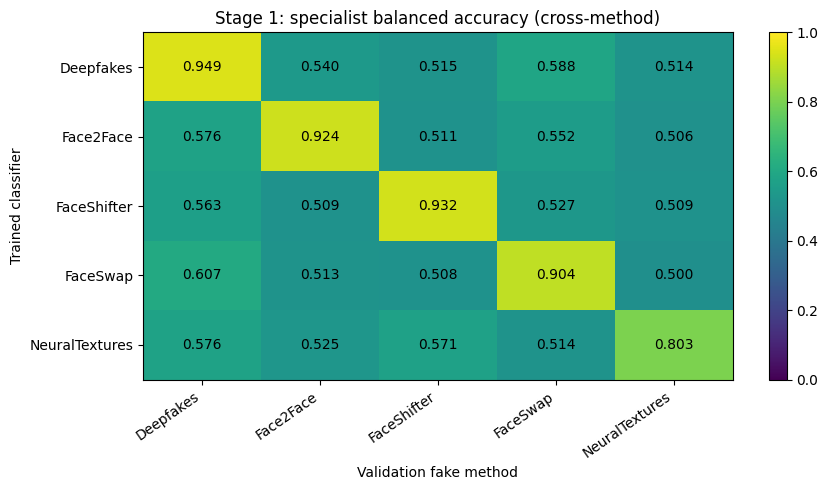

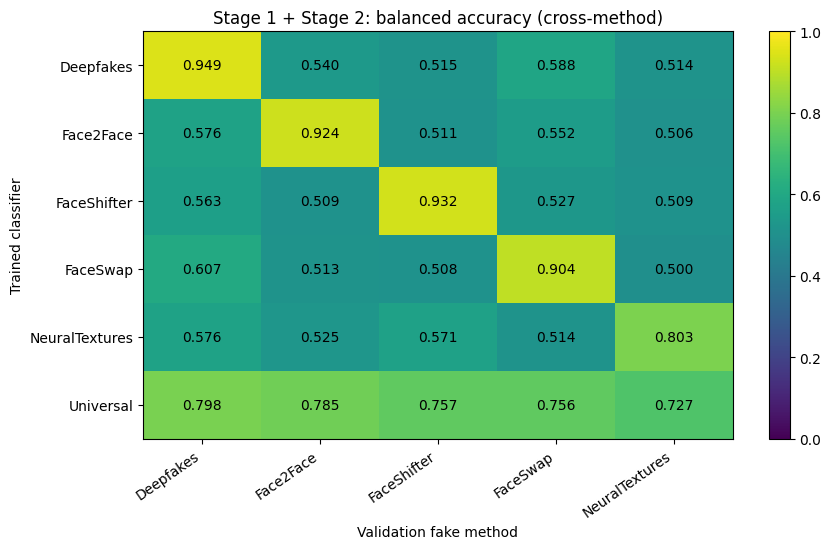

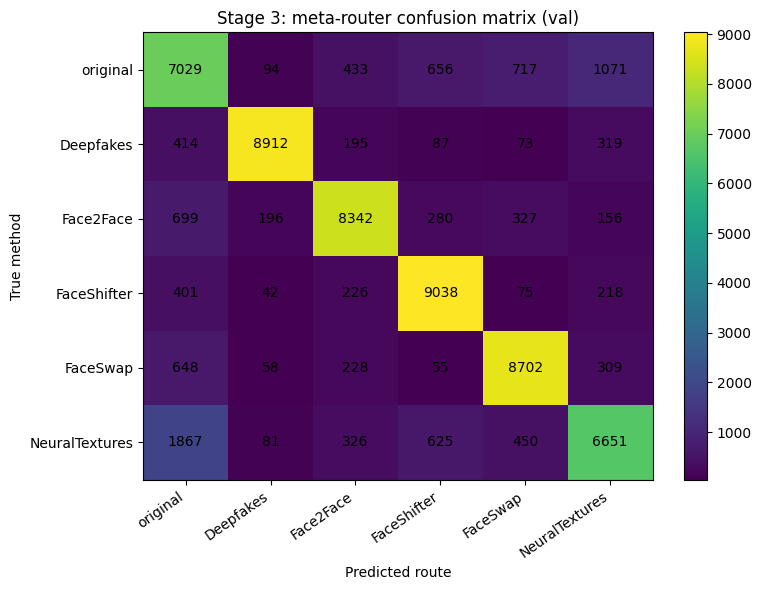

In [17]:
def plot_metric_matrix(matrix_df: pd.DataFrame, row_order, col_order, title: str, out_name: str):
    matrix = matrix_df.pivot(index="classifier", columns="test_method", values="balanced_accuracy").loc[
        row_order, col_order
    ]
    fig, ax = plt.subplots(figsize=(9, max(3, 0.6 * len(row_order) + 2)))
    im = ax.imshow(matrix.to_numpy(), vmin=0.0, vmax=1.0, aspect="auto")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=35, ha="right")
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel("Validation fake method")
    ax.set_ylabel("Trained classifier")
    ax.set_title(title)
    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, f"{matrix.iloc[r, c]:.3f}", ha="center", va="center")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    out_path = PLOT_ROOT / out_name
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return out_path


plot_metric_matrix(
    stage1_matrix, SPECIALIST_EXPERIMENTS, FAKE_METHODS,
    "Stage 1: specialist balanced accuracy (cross-method)", "stage1_balanced_accuracy_matrix.png",
)

combined_matrix = pd.concat([stage1_matrix, stage2_per_method], ignore_index=True)
plot_metric_matrix(
    combined_matrix, [*SPECIALIST_EXPERIMENTS, UNIVERSAL_EXPERIMENT], FAKE_METHODS,
    "Stage 1 + Stage 2: balanced accuracy (cross-method)", "stage1_stage2_balanced_accuracy_matrix.png",
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(router_val_metrics["confusion_matrix"], aspect="auto")
ax.set_xticks(range(len(ROUTER_CLASSES)))
ax.set_xticklabels(ROUTER_CLASSES, rotation=35, ha="right")
ax.set_yticks(range(len(ROUTER_CLASSES)))
ax.set_yticklabels(ROUTER_CLASSES)
ax.set_xlabel("Predicted route")
ax.set_ylabel("True method")
ax.set_title("Stage 3: meta-router confusion matrix (val)")
for r in range(router_val_metrics["confusion_matrix"].shape[0]):
    for c in range(router_val_metrics["confusion_matrix"].shape[1]):
        ax.text(c, r, str(router_val_metrics["confusion_matrix"][r, c]), ha="center", va="center")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(PLOT_ROOT / "stage3_router_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

## 15. Package outputs

In [18]:
run_configuration = {
    "DATASET_ROOT": str(DATASET_ROOT),
    "artifact_root": str(ARTIFACT_ROOT),
    "architecture": "Xception (Cadene/FF++ style, full fine-tune)",
    "pretrained_weights_path": XCEPTION_PRETRAINED_WEIGHTS_PATH,
    "random_seed": RANDOM_SEED,
    "specialist_experiments": SPECIALIST_EXPERIMENTS,
    "universal_experiment": UNIVERSAL_EXPERIMENT,
    "router_classes": ROUTER_CLASSES,
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "crop_size": CROP_SIZE,
    "smoke_test": SMOKE_TEST,
}
with (ARTIFACT_ROOT / "run_configuration.json").open("w") as f:
    json.dump(run_configuration, f, indent=2)

LIGHT_EXPORT = WORKING_DIR / "ffpp_xception_models_metadata"
if LIGHT_EXPORT.exists():
    shutil.rmtree(LIGHT_EXPORT)
LIGHT_EXPORT.mkdir(parents=True)

for source in [CHECKPOINT_ROOT, RESULT_ROOT, PLOT_ROOT, RUN_METADATA_ROOT, PREDICTION_BANK_ROOT]:
    shutil.copytree(source, LIGHT_EXPORT / source.name, dirs_exist_ok=True)
shutil.copy2(ARTIFACT_ROOT / "run_configuration.json", LIGHT_EXPORT / "run_configuration.json")

archive_path = shutil.make_archive(
    str(WORKING_DIR / "ffpp_xception_models_metadata"), "zip", root_dir=str(LIGHT_EXPORT)
)

print("\n" + "=" * 80)
print("DONE")
print("=" * 80)
print("Stage 1 checkpoints:")
for name in SPECIALIST_EXPERIMENTS:
    print(f"  {name:16s} -> {CHECKPOINT_ROOT / name / 'model_weights.pth'}")
print(f"Stage 2 checkpoint:  {UNIVERSAL_EXPERIMENT:16s} -> {CHECKPOINT_ROOT / UNIVERSAL_EXPERIMENT / 'model_weights.pth'}")
print(f"Stage 3 checkpoint:  {ROUTER_EXPERIMENT:16s} -> {CHECKPOINT_ROOT / ROUTER_EXPERIMENT / 'model_weights.pth'}")
print(f"\nResults directory: {RESULT_ROOT}")
print(f"Plots directory: {PLOT_ROOT}")
print(f"Lightweight ZIP: {archive_path}")
print("\nUse Kaggle 'Save Version' to persist /kaggle/working outputs.")


DONE
Stage 1 checkpoints:
  Deepfakes        -> /kaggle/working/ffpp_xception_training_artifacts/checkpoints/Deepfakes/model_weights.pth
  Face2Face        -> /kaggle/working/ffpp_xception_training_artifacts/checkpoints/Face2Face/model_weights.pth
  FaceShifter      -> /kaggle/working/ffpp_xception_training_artifacts/checkpoints/FaceShifter/model_weights.pth
  FaceSwap         -> /kaggle/working/ffpp_xception_training_artifacts/checkpoints/FaceSwap/model_weights.pth
  NeuralTextures   -> /kaggle/working/ffpp_xception_training_artifacts/checkpoints/NeuralTextures/model_weights.pth
Stage 2 checkpoint:  Universal        -> /kaggle/working/ffpp_xception_training_artifacts/checkpoints/Universal/model_weights.pth
Stage 3 checkpoint:  MetaRouter       -> /kaggle/working/ffpp_xception_training_artifacts/checkpoints/MetaRouter/model_weights.pth

Results directory: /kaggle/working/ffpp_xception_training_artifacts/results
Plots directory: /kaggle/working/ffpp_xception_training_artifacts/plots
Li